# ReAct Agent Architecture

## ReAct Agent

A ReAct (Reason and Act) agent is an AI architecture that combines chain-of-thought reasoning with external tool execution, while agent memory provides the context and continuity required to handle multi-step and multi-turn tasks

## The ReAct Framework (Reason + Act)

- Thought: The agent analyzes the user request and plans the next step using an internal monologue or reasoning trace.
- Action: The agent selects and calls an external tool (such as a calculator, web search, or database query).
- Observation: The agent receives and evaluates the output returned by the tool.
- Loop: It repeats this sequence—Thought → Action → Observation—until it gathers enough information to formulate a final response.

## ReAct Agent Architecture

The ReAct (Reasoning + Acting) architecture in LangGraph is an iterative loop pattern designed to give Large Language Models (LLMs) the ability to alternate between "thinking" and "executing actions" using tools.

The 4 Core Architectural Components:
LangGraph maps the ReAct pattern directly into a Stateful Graph using four primary building blocks:
1. **The Graph State (Shared Memory)**: A centralized data structure (usually containing a list of messages) that flows through every part of the agent. Each step reads from this state and appends its updates (like LLM thoughts or tool results).
2. **The Assistant/LLM Node (Reasoning)**: The brain of the graph. It receives the conversation history, applies reasoning, and outputs either a final natural language answer or a request to execute a tool (a tool_call).
3. **The Tools Node (Acting)**: A node containing python functions (e.g., web search, databases, APIs). If the LLM requests a tool, this node executes it and converts the output into a ToolMessage.
4. **Conditional Edges (Routing)**: The decision-making tracks that evaluate the LLM's response. If a tool call is present, it routes the graph to the Tools Node. If no tool call is needed, it routes the graph to the END node to respond to the user.

This is the intuition behind ReAct, a general agent architecture.

1. act - let the model call specific tools
2. observe - pass the tool output back to the model
3. reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

## Using Arxiv as a Tool

### Importing Arxiv Tool

In [5]:
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper

api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


### Invoking the Arxiv Tool

In [6]:
result = arxiv.invoke("Attention is all you need")
print(result)

HTTPError: Page request resulted in HTTP 301: None (http://export.arxiv.org/api/query?search_query=Attention+is+all+you+need&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=2)

### Arxiv Package Compatibility Note

The `arxiv` python package updated and dropped `.results()`, which completely broke the LangChain wrapper. Easiest fix right now is to just downgrade your arxiv package in your venv.

Run this in your terminal:

```bash
pip install arxiv==1.4.8
```

Restart your Jupyter notebook kernel after running that and your exact code should work fine without any changes.


## Using Wikipedia as a Tool

### Importing Wikipedia Tool

In [7]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


### Invoking the Wikipedia Tool

In [8]:
wiki.invoke("What is Avengers: Doomsday")

'Page: Avengers: Doomsday\nSummary: Avengers: Doomsday is an upcoming American superhero film based on the Marvel Comics superhero team the Avengers. Produced by Marvel Studios and distributed by Walt Disney Studios Motion Pictures, it is intended to be the sequel to Avengers: Endgame (2019) and the 39th film in the Marvel Cinematic Universe (MCU). Directed by Anthony and Joe Russo, and written by Michael Waldron, Stephen McFeely, and the writing team of Chris McKenna and Erik Sommers, the film fe'

## Using Tavily Search as a Tool

### Loading Environment Variables

In [10]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("groq_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] ="true"
os.environ["LANGCHAIN_PROJECT"]="ReAct-Agent"

### Custom Functions

In [11]:
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools=[wiki,add,multiply,divide]

### Importing Tavily Search

In [12]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily=TavilySearchResults()

C:\Users\devgo\AppData\Local\Temp\ipykernel_11208\3880125110.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily=TavilySearchResults()


### Invoking the Tavily Tool

In [13]:
tavily.invoke("Will Thor returns in Avengers: Doomsday")

[{'title': 'Thor returns for Avengers Doomsday 🔨 ⚡️ 12.18.2026',
  'url': 'https://www.facebook.com/chrishemsworth/videos/thor-returns-for-avengers-doomsday-%EF%B8%8F-12182026/1951645738743795',
  'content': 'Thor returns for Avengers Doomsday ⚡️ 12.18.2026. Nobody will ever replace Chris Hemsworth as Thor. He is Thor.',
  'score': 0.91490877},
 {'title': 'Avengers: Doomsday’s Version Of Thor Is Finally Confirmed By The Russo Brothers',
  'url': 'https://screenrant.com/avengers-doomsday-thor-russo-brothers-confirm',
  'content': "It’s been 15 years since Chris Hemsworth debuted as the Marvel Cinematic Universe’s Thor, and Avengers: Doomsday marks his 10th appearance as the Asgardian God of Thunder. Hemsworth reunited with directors Joe and Anthony Russo on the 2026 movie, who previously worked with the actor on Avengers: Infinity War and Avengers: Endgame. The filmmakers have confirmed that Thor jumping back into action in Doomsday will resemble how he was presented in one of those pre

### Searching Recent Information

In [14]:
tavily.invoke("Provide me the recent AI news for 29 September 2026")

[{'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
  'url': 'https://www.artificialintelligence-news.com',
  'content': '### AI & Big Data Expo Europe 2026\n\n19 October 2026 8:30 am\n\nto\n\n20 October 2026 4:00 pm\n\nRAI\n\nin\n\nAmsterdam\n\n## Related News\n\n[](\n\nDeveloper Tech News\n\nSeptember 29, 2026\n\n## AI coding agents are raising the stakes for SAST\n\n[](\n\nAI News\n\nSeptember 29, 2026\n\n## AI Security Needs a Chain of Provenance From Context to Action\n\n[](\n\nAI News\n\nSeptember 29, 2026\n\n## What AMD’s World Labs acquisition means for enterprises building with world models\n\n[](\n\nDeveloper Tech News\n\nSeptember 28, 2026\n\n## Artificial Analysis Cyber Index tests defensive AI security models\n\n[](\n\nAI News\n\nSeptember 28, 2026\n\n## Oracle Fusion drives supply chain planning for Combe\n\n[](\n\nTelecoms Tech News\n\nSeptember 28, 2026\n\n## Ahead of the ask\n\nManage Cookie Consent [...] Physical AI\n\n# What AMD’s World 

## Combining Multiple Tools

### Creating the Tools List

In [15]:
tools=[wiki,tavily,add,multiply,divide]

### Initializing the Chat Model and Binding Tools with Chat Model

In [16]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-120b")

llm_with_tools=llm.bind_tools(tools)

### Invoking the LLM with Tools

In [18]:
from langchain_core.messages import HumanMessage, AIMessage
from pprint import pprint

llm_with_tools.invoke([HumanMessage(content=f"Who will be playing Doctor Doom role in Avengers: Doomsday")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "Who will be playing Doctor Doom role in Avengers: Doomsday". Need to answer. Likely a recent news about a Marvel movie "Avengers: Doomsday". Need to verify. Use search.', 'tool_calls': [{'id': 'fc_f2da5b18-e0c6-4cf4-86b4-0caf94b36311', 'function': {'arguments': '{"query":"Avengers: Doomsday Doctor Doom actor"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 87, 'prompt_tokens': 312, 'total_tokens': 399, 'completion_time': 0.183832069, 'completion_tokens_details': {'reasoning_tokens': 48}, 'prompt_time': 0.01555767, 'prompt_tokens_details': None, 'queue_time': 0.397760369, 'total_time': 0.199389739}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_bb691ea66b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0f148-d019-7e02-843c-3c0c8e81895d-0', tool_cal

### Viewing Tool Calls

In [19]:
llm_with_tools.invoke([HumanMessage(content=f"Who will be playing Doctor Doom role in Avengers: Doomsday")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'Avengers: Doomsday Doctor Doom actor'},
  'id': 'fc_5d4d750d-b762-4b52-b76b-795bed8a188a',
  'type': 'tool_call'}]

## Building the LangGraph

### Importing Required Modules

In [20]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message  import add_messages

### Defining the State Schema

In [21]:
class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

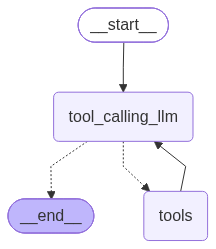

In [23]:
### Importing LangGraph Components
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

### Defining the Tool Calling Node
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

### Creating the StateGraph
builder=StateGraph(State)

### Adding the Node
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

### Adding the Edges
builder.add_edge(START, "tool_calling_llm")

# If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
# If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
builder.add_conditional_edges("tool_calling_llm", tools_condition)

builder.add_edge("tools", "tool_calling_llm")

### Compiling the Graph
graph=builder.compile()

### Displaying the Graph
display(Image(graph.get_graph().draw_mermaid_png()))

### Running the Chatbot with Arxiv

In [24]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_c8a55e9e-9206-47ca-981d-573301b81fb1)
 Call ID: fc_c8a55e9e-9206-47ca-981d-573301b81fb1
  Args:
    query: arXiv 1706.03762
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "1706.03762v7.pdf", "url": "https://arxiv.org/pdf/1706.03762", "content": "> ∗\n\nEqual contribution. Listing order is random. Jakob proposed replacing RNNs with self-attention and started the effort to evaluate this idea. Ashish, with Illia, designed and implemented the first Transformer models and has been crucially involved in every aspect of this work. Noam proposed scaled dot-product attention, multi-head attention and the parameter-free position representation and became the other person involved in nearly every detail.

### Running the Chatbot with Wikipedia

In [25]:
messages=graph.invoke({"messages":HumanMessage(content="Give me Robert Downey Jr movies featuring in MCU, add 10 plus 20 and then multiply by 5")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me Robert Downey Jr movies featuring in MCU, add 10 plus 20 and then multiply by 5
================================== Ai Message ==================================

**Robert Downey Jr. movies in the Marvel Cinematic Universe (MCU)**  

| # | Film (Release Year) | Role |
|---|----------------------|------|
| 1 | *Iron Man* (2008) | Tony Stark / Iron Man |
| 2 | *Iron Man 2* (2010) | Tony Stark / Iron Man |
| 3 | *The Avengers* (2012) | Tony Stark / Iron Man |
| 4 | *Iron Man 3* (2013) | Tony Stark / Iron Man |
| 5 | *Avengers: Age of Ultron* (2015) | Tony Stark / Iron Man |
| 6 | *Captain America: Civil War* (2016) | Tony Stark / Iron Man |
| 7 | *Spider‑Man: Homecoming* (2017) – cameo / mentor | Tony Stark / Iron Man |
| 8 | *Avengers: Infinity War* (2018) | Tony Stark / Iron Man |
| 9 | *Avengers: Endgame* (2019) | Tony Stark / Iron Man |

*(These are all the MCU feature‑film appearances of Robert D

### Running the Chatbot with Tavily Search

In [28]:
messages=graph.invoke({"messages":HumanMessage(content="Who is Dev Goyal from Capgemini")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Who is Dev Goyal from Capgemini
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_ab4ef7ac-8e35-4f24-8a58-c2e74f8b6e2d)
 Call ID: fc_ab4ef7ac-8e35-4f24-8a58-c2e74f8b6e2d
  Args:
    query: Dev Goyal Capgemini
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Dev Goyal", "url": "https://in.linkedin.com/in/devgoyalg", "content": "- 𝐄𝐱𝐜𝐢𝐭𝐞𝐝 𝐭𝐨 𝐬𝐡𝐚𝐫𝐞 𝐭𝐡𝐚𝐭 𝐈 𝐡𝐚𝐯𝐞 𝐬𝐮𝐜𝐜𝐞𝐬𝐬𝐟𝐮𝐥𝐥𝐲 𝐜𝐨𝐦𝐩𝐥𝐞𝐭𝐞𝐝 𝐦𝐲 \"𝐃𝐚𝐭𝐚 𝐀𝐧𝐚𝐥𝐲𝐬𝐭 𝐈𝐧𝐭𝐞𝐫𝐧𝐬𝐡𝐢𝐩\" 𝐚𝐭 Capgemini , 𝐰𝐡𝐢𝐜𝐡 𝐜𝐨𝐧𝐜𝐥𝐮𝐝𝐞𝐝 𝐨𝐧 2𝐧𝐝 𝐉𝐮𝐧𝐞 2026! 🤩🎉 These two months have been an incredible journey filled with learning, growth, and valuable experiences. From understanding real-world business problems to working with industry-standard tools. 𝗧𝗵𝗿𝗼𝘂𝗴𝗵𝗼𝘂𝘁 𝘁𝗵𝗲 𝗶𝗻𝘁𝗲𝗿𝗻𝘀𝗵𝗶𝗽, 𝗜 𝗵𝗮𝗱 𝘁𝗵𝗲 𝗼𝗽𝗽𝗼𝗿𝘁𝘂𝗻𝗶𝘁𝘆 𝘁𝗼 𝗹𝗲𝗮𝗿𝗻 𝗮𝗻𝗱 𝘄𝗼𝗿𝗸 𝘄𝗶𝘁𝗵: -> Python | SQL | Oracle SQL | 

# Agent Memory

### Running the First Query

In [29]:
messages=graph.invoke({"messages":HumanMessage(content="What is 2 plus 3")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 plus 3
================================== Ai Message ==================================

2 + 3 = 5.


### Running a Follow-up Query

In [30]:
messages=graph.invoke({"messages":HumanMessage(content="Divide that by 5")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================

I’m not sure which number you’d like to divide by 5. Could you let me know the value you want to use?


## Memory Saver

- LangGraph can use a checkpointer to automatically save the graph state after each step.
- This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update.
- One of the easiest checkpointers to use is the MemorySaver, an in-memory key-value store for Graph state.
- All we need to do is simply compile the graph with a checkpointer, and our graph has memory!

### Building the LangGraph

In [ ]:
### Importing LangGraph Components
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

### Defining the Tool Calling Node
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

### Creating the StateGraph
builder=StateGraph(State)

### Adding the Node
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

### Adding the Edges
builder.add_edge(START, "tool_calling_llm")

# If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
# If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
builder.add_conditional_edges("tool_calling_llm", tools_condition)

### Adding the Tool Calling Loop
builder.add_edge("tools", "tool_calling_llm")

### Creating the Memory Saver

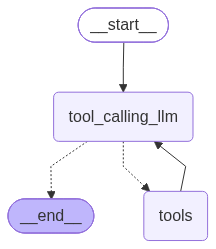

In [ ]:
### Creating the Memory Saver
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

### Compiling the Graph with Memory
graph_memory=builder.compile(checkpointer=memory)

### Displaying the Graph
display(Image(graph_memory.get_graph().draw_mermaid_png()))

### Creating a Thread Configuration and Running the First Query

In [ ]:
### Creating a Thread Configuration
config={"configurable":{"thread_id":"1"}}

### Running the First Query
messages=[HumanMessage(content="Add 18 and 45")]
messages=graph_memory.invoke({"messages":messages}, config=config)
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 18 and 45
================================== Ai Message ==================================
Tool Calls:
  add (fc_efb9b831-100c-4f14-af78-5f0339a0fdf9)
 Call ID: fc_efb9b831-100c-4f14-af78-5f0339a0fdf9
  Args:
    a: 18
    b: 45
================================= Tool Message =================================
Name: add

63
================================== Ai Message ==================================

The sum of 18 and 45 is **63**.


### Running a Follow-up Query

In [36]:
messages=[HumanMessage(content="Add that number to 7")]
messages=graph_memory.invoke({"messages":messages}, config=config)
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 18 and 45
================================== Ai Message ==================================
Tool Calls:
  add (fc_efb9b831-100c-4f14-af78-5f0339a0fdf9)
 Call ID: fc_efb9b831-100c-4f14-af78-5f0339a0fdf9
  Args:
    a: 18
    b: 45
================================= Tool Message =================================
Name: add

63
================================== Ai Message ==================================

The sum of 18 and 45 is **63**.
================================ Human Message =================================

Add that number to 7
================================== Ai Message ==================================
Tool Calls:
  add (fc_878e60a5-7de8-45f5-8690-5f19d219bf9f)
 Call ID: fc_878e60a5-7de8-45f5-8690-5f19d219bf9f
  Args:
    a: 63
    b: 7
================================= Tool Message =================================
Name: add

70
================================== Ai Message ==============

### Running Another Follow-up Query

In [38]:
messages=[HumanMessage(content="Multiply that number by 5")]
messages=graph_memory.invoke({"messages":messages}, config=config)
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 18 and 45
================================== Ai Message ==================================
Tool Calls:
  add (fc_efb9b831-100c-4f14-af78-5f0339a0fdf9)
 Call ID: fc_efb9b831-100c-4f14-af78-5f0339a0fdf9
  Args:
    a: 18
    b: 45
================================= Tool Message =================================
Name: add

63
================================== Ai Message ==================================

The sum of 18 and 45 is **63**.
================================ Human Message =================================

Add that number to 7
================================== Ai Message ==================================
Tool Calls:
  add (fc_878e60a5-7de8-45f5-8690-5f19d219bf9f)
 Call ID: fc_878e60a5-7de8-45f5-8690-5f19d219bf9f
  Args:
    a: 63
    b: 7
================================= Tool Message =================================
Name: add

70
================================== Ai Message ==============